# Problem Set III - Question 1: Quantum Fourier Transform

**Course:** QPROG - Quantum Programming  
**Students:** Jady Pâmella Barbacena da Silva and Navyashree Suryanarayana Rao Prasanna
**Group:** Group ProblemSet-III-N  
**Assignment:** Implementation of QFT  

This notebook implements the Quantum Fourier Transform (QFT) in Qiskit.

## Environment Setup

Install required packages.

In [1]:
%pip install qiskit==2.2.3
%pip install qiskit-aer==0.17.2
%pip install matplotlib
%pip install numpy
%pip install pylatexenc

Note: you may need to restart the kernel to use updated packages.


Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.




In [2]:
# Import required libraries
from qiskit import QuantumCircuit, transpile
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import numpy as np

## Task 1.2: Implement apply_qft

Implement the Quantum Fourier Transform acting on the first n qubits.

In [ ]:
def apply_qft(n, circuit):
    """
    Apply QFT on the first n qubits of the circuit.
    
    Args:
        n: Number of qubits to apply QFT to
        circuit: QuantumCircuit to modify
    """
    # For each qubit j from n-1 down to 0
    for j in range(n-1, -1, -1):
        # Apply Hadamard gate on qubit j
        circuit.h(j)
        
        # Apply controlled phase gates
        for k in range(j-1, -1, -1):
            # Phase shift: π/2^(j-k)
            circuit.cp(np.pi / 2**(j-k), k, j)
    
    # Swap qubits to reverse the order
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)
    
    return circuit

## Task 1.3: Implement Inverse QFT

Implement the Inverse Quantum Fourier Transform by reversing gates and negating phases.

In [ ]:
def apply_iqft(n, circuit):
    """
    Apply Inverse QFT on the first n qubits of the circuit.
    
    The inverse is obtained by:
    1. Reversing the order of operations from apply_qft
    2. Using inverse of each gate (Hadamard and swap are self-inverse, phase shift negated)
    
    Args:
        n: Number of qubits to apply Inverse QFT to
        circuit: QuantumCircuit to modify
    """
    # First, swap qubits (reverse of the final step in QFT)
    for i in range(n // 2):
        circuit.swap(i, n - i - 1)
    
    # Apply inverse rotations in reverse order
    for j in range(n):
        # Apply inverse controlled phase gates (in reverse order with negative angles)
        for k in range(j):
            # Negative phase shift: -π/2^(j-k)
            circuit.cp(-np.pi / 2**(j-k), k, j)
        
        # Apply Hadamard gate (self-inverse)
        circuit.h(j)
    
    return circuit

## Task 1.4: Generalized QFT Functions

Generalize QFT and Inverse QFT to work on arbitrary lists of qubits.

In [ ]:
def apply_qft_gen(qubits, circuit):
    """
    Apply QFT on the qubits specified in the list.
    
    Args:
        qubits: List of qubit indices to apply QFT to
        circuit: QuantumCircuit to modify
    """
    n = len(qubits)
    
    # For each qubit j from n-1 down to 0
    for j in range(n-1, -1, -1):
        # Apply Hadamard gate on qubits[j]
        circuit.h(qubits[j])
        
        # Apply controlled phase gates
        for k in range(j-1, -1, -1):
            # Phase shift: π/2^(j-k)
            circuit.cp(np.pi / 2**(j-k), qubits[k], qubits[j])
    
    # Swap qubits to reverse the order
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - i - 1])
    
    return circuit


def apply_iqft_gen(qubits, circuit):
    """
    Apply Inverse QFT on the qubits specified in the list.
    
    Args:
        qubits: List of qubit indices to apply Inverse QFT to
        circuit: QuantumCircuit to modify
    """
    n = len(qubits)
    
    # First, swap qubits
    for i in range(n // 2):
        circuit.swap(qubits[i], qubits[n - i - 1])
    
    # Apply inverse rotations in reverse order
    for j in range(n):
        # Apply inverse controlled phase gates
        for k in range(j):
            # Negative phase shift: -π/2^(j-k)
            circuit.cp(-np.pi / 2**(j-k), qubits[k], qubits[j])
        
        # Apply Hadamard gate
        circuit.h(qubits[j])
    
    return circuit

## Test Task 1.2: apply_qft with n=3

Test the apply_qft function as specified in the assignment (Figure 1).

QFT Circuit with 3 qubits:
                                          ┌───┐   
q_0: ──────■──────────────────────■───────┤ H ├─X─
           │                ┌───┐ │P(π/2) └───┘ │ 
q_1: ──────┼────────■───────┤ H ├─■─────────────┼─
     ┌───┐ │P(π/4)  │P(π/2) └───┘               │ 
q_2: ┤ H ├─■────────■───────────────────────────X─
     └───┘                                        



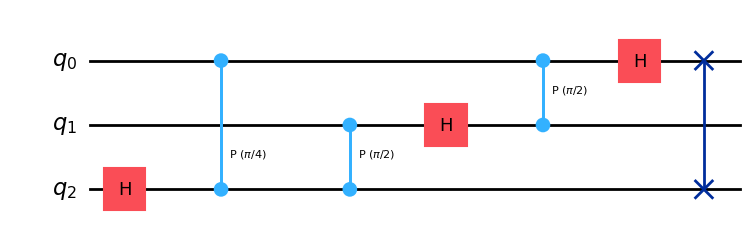

In [ ]:
n = 3
circuit = QuantumCircuit(n, 0)
apply_qft(n, circuit)
print("Task 1.2 - QFT on 3 qubits:")
print(circuit)
print()
circuit.draw('mpl')

QFT Circuit with initial state |0001⟩:
        ┌───┐                                                                »
   q_0: ┤ X ├─■───────────────────────────────■──────────────────────■───────»
        └───┘ │                               │                ┌───┐ │P(π/2) »
   q_1: ──────┼────────■──────────────────────┼────────■───────┤ H ├─■───────»
              │        │                ┌───┐ │P(π/4)  │P(π/2) └───┘         »
   q_2: ──────┼────────┼────────■───────┤ H ├─■────────■─────────────────────»
        ┌───┐ │P(π/8)  │P(π/4)  │P(π/2) └───┘                                »
   q_3: ┤ H ├─■────────■────────■────────────────────────────────────────────»
        └───┘                                                                »
meas: 4/═════════════════════════════════════════════════════════════════════»
                                                                             »
«        ┌───┐    ░ ┌─┐         
«   q_0: ┤ H ├─X──░─┤M├─────────
«        └───┘ │  ░ └╥┘┌─┐

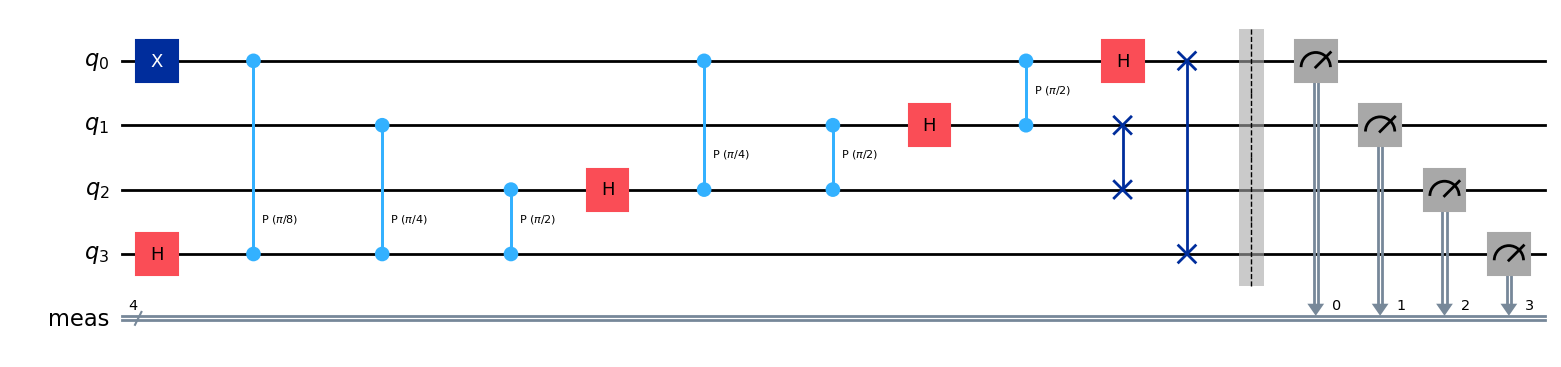

In [ ]:
# Test with n=4 (Figure 2)
n = 4
circuit = QuantumCircuit(n, 0)
apply_qft(n, circuit)
print("Task 1.2 - QFT on 4 qubits:")
print(circuit)
print()
circuit.draw('mpl')

## Test Task 1.3: Inverse QFT

Test apply_iqft with n=4 (Figure 3 in PDF).

In [ ]:
n = 4
circuit = QuantumCircuit(n, 0)
apply_iqft(n, circuit)
print("Task 1.3 - Inverse QFT on 4 qubits:")
print(circuit)
print()
circuit.draw('mpl')

## Test Task 1.4: Generalized QFT

Test apply_qft_gen and apply_iqft_gen on arbitrary qubit lists.

In [ ]:
# Test generalized QFT on qubits [0, 2, 4]
circuit = QuantumCircuit(5, 0)
qubits = [0, 2, 4]
apply_qft_gen(qubits, circuit)
print(f"Task 1.4 - Generalized QFT on qubits {qubits}:")
print(circuit)
print()
circuit.draw('mpl')

In [ ]:
# Test generalized Inverse QFT
circuit = QuantumCircuit(5, 0)
qubits = [1, 2, 3]
apply_iqft_gen(qubits, circuit)
print(f"Task 1.4 - Generalized Inverse QFT on qubits {qubits}:")
print(circuit)
print()
circuit.draw('mpl')

## Verification: QFT and Inverse QFT

Verify that QFT followed by Inverse QFT returns the original state.

Measurement results:
{'011': 114, '111': 134, '100': 136, '010': 124, '000': 136, '001': 116, '101': 125, '110': 139}



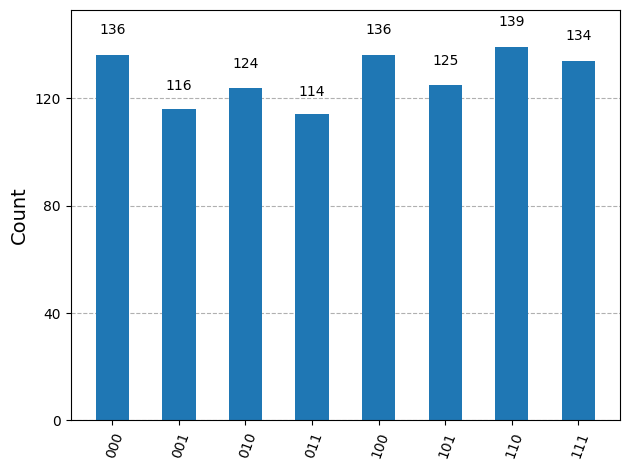

In [ ]:
# Verify QFT * IQFT = Identity
n = 3
circuit = QuantumCircuit(n, n)

# Prepare initial state
circuit.x(0)
circuit.h(1)

# Apply QFT then Inverse QFT
apply_qft(n, circuit)
apply_iqft(n, circuit)

# Measure
circuit.measure([0, 1, 2], [0, 1, 2])

simulator = AerSimulator()
compiled_circuit = transpile(circuit, simulator)
result = simulator.run(compiled_circuit, shots=1024).result()
counts = result.get_counts()

print("Verification: QFT * IQFT = Identity")
print("Initial state: |1>|+>|0>")
print("After QFT then IQFT:")
print(counts)
print("Expected: '010' and '011' with ~50% each")
print()
plot_histogram(counts)

## Summary

All tasks completed:
- ✓ Task 1.2: apply_qft (QFT on first n qubits)
- ✓ Task 1.3: apply_iqft (Inverse QFT with negative phases)
- ✓ Task 1.4: apply_qft_gen and apply_iqft_gen (Generalized versions)

Total: 3 points